In [ ]:
!pip install -q tensorflow pillow scikit-learn

import os, json, zipfile, glob, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
ZIP_FILE = "images.zip"
CSV_FILE = "dataset.csv"
LABEL_MAP_FILE = "label_map.json"

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall("/content/extracted_dataset")

df = pd.read_csv(CSV_FILE)

with open(LABEL_MAP_FILE, "r") as f:
    label_map = json.load(f)

id_to_class = {v: k for k, v in label_map.items()}
NUM_CLASSES = len(label_map)

print(df.head())
print(label_map)

     image_path                   text  label class_name
0  images/0.jpg  tshirt fashion outfit      7     tshirt
1  images/1.jpg  tshirt fashion outfit      7     tshirt
2  images/2.jpg  tshirt fashion outfit      7     tshirt
3  images/3.jpg  tshirt fashion outfit      7     tshirt
4  images/4.jpg  tshirt fashion outfit      7     tshirt
{'dress': 0, 'glasses': 1, 'hoodie': 2, 'jacket': 3, 'jeans': 4, 'shorts': 5, 'sneakers': 6, 'tshirt': 7}


In [ ]:
PATH_COL = "full_image_path" if "full_image_path" in df.columns else "image_path"

def fix_path(path):
    path = str(path)

    if os.path.exists(path):
        return path

    filename = os.path.basename(path)

    matches = glob.glob(f"/content/extracted_dataset/**/{filename}", recursive=True)

    if len(matches) > 0:
        return matches[0]

    return path

df[PATH_COL] = df[PATH_COL].apply(fix_path)
df = df[df[PATH_COL].apply(os.path.exists)].reset_index(drop=True)

print("Total valid images:", len(df))
print(df.head())

Total valid images: 518
                                image_path                   text  label  \
0  /content/extracted_dataset/images/0.jpg  tshirt fashion outfit      7   
1  /content/extracted_dataset/images/1.jpg  tshirt fashion outfit      7   
2  /content/extracted_dataset/images/2.jpg  tshirt fashion outfit      7   
3  /content/extracted_dataset/images/3.jpg  tshirt fashion outfit      7   
4  /content/extracted_dataset/images/4.jpg  tshirt fashion outfit      7   

  class_name  
0     tshirt  
1     tshirt  
2     tshirt  
3     tshirt  
4     tshirt  


In [ ]:
if "label" not in df.columns:
    if "class_name" in df.columns:
        df["label"] = df["class_name"].map(label_map)
    else:
        raise ValueError("No label or class_name column found.")

if "class_name" not in df.columns:
    df["class_name"] = df["label"].map(id_to_class)

df["label"] = df["label"].astype(int)

print(df["class_name"].value_counts())

class_name
jeans       77
tshirt      69
dress       65
glasses     65
sneakers    62
jacket      60
shorts      60
hoodie      60
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 362
Validation: 78
Test: 78


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df[PATH_COL].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df[PATH_COL].values, val_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df[PATH_COL].values, test_df["label"].values)
)

train_ds = train_ds.map(load_image).shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="mobilenet_feature_vector")(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = tf.keras.Model(inputs, outputs, name="MobileNetV2_CNN_Classifier")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")
    ]
)

cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_CNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_feature_vector        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
os.makedirs("/content/models", exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_mobilenet_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.2649 - loss: 2.2731 - top3_acc: 0.4958
Epoch 1: val_accuracy improved from None to 0.62821, saving model to /content/models/best_mobilenet_cnn.keras

Epoch 1: finished saving model to /content/models/best_mobilenet_cnn.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.3646 - loss: 1.8705 - top3_acc: 0.6409 - val_accuracy: 0.6282 - val_loss: 1.0808 - val_top3_acc: 0.8846 - learning_rate: 0.0010
Epoch 2/20
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6541 - loss: 0.9857 - top3_acc: 0.9073
Epoch 2: val_accuracy improved from 0.62821 to 0.70513, saving model to /content/models/best_mobilenet_cnn.keras

Epoch 2: finished saving model to /content/models/best_mobilenet_cnn.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6906 - loss: 0.9036 - top3_acc: 0.9171 - val_accuracy: 0.7051 - val_loss: 0.8336 - val_top3_acc: 0.9103 - learning_rate: 0.0010
Epoch 3/20
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - 

In [ ]:
cnn_model = tf.keras.models.load_model("/content/models/best_mobilenet_cnn.keras")

test_loss, test_acc, test_top3 = cnn_model.evaluate(test_ds)

print("MobileNet CNN Test Accuracy:", test_acc)
print("MobileNet CNN Test Top-3 Accuracy:", test_top3)

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 987ms/step - accuracy: 0.6282 - loss: 1.0064 - top3_acc: 0.9359
MobileNet CNN Test Accuracy: 0.6282051205635071
MobileNet CNN Test Top-3 Accuracy: 0.9358974099159241


In [ ]:
def cnn_predict(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    pred = cnn_model.predict(img, verbose=0)[0]

    class_id = int(np.argmax(pred))
    class_name = id_to_class[class_id]
    confidence = float(pred[class_id])

    return class_id, class_name, confidence, pred

In [ ]:
def show_top3_predictions(index):
    row = df.iloc[index]
    image_path = row[PATH_COL]
    true_class = row["class_name"]

    class_id, predicted_class, confidence, pred = cnn_predict(image_path)

    top3_ids = np.argsort(pred)[-3:][::-1]

    img = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class} ({confidence:.2%})"
    )
    plt.show()

    print("Index:", index)
    print("Image:", image_path)
    print("True class:", true_class)
    print("Predicted item:", predicted_class)

    print("\nTop 3 predictions:")
    for rank, cid in enumerate(top3_ids, start=1):
        cid = int(cid)
        print(f"{rank}. {id_to_class[cid]}: {pred[cid]:.2%}")

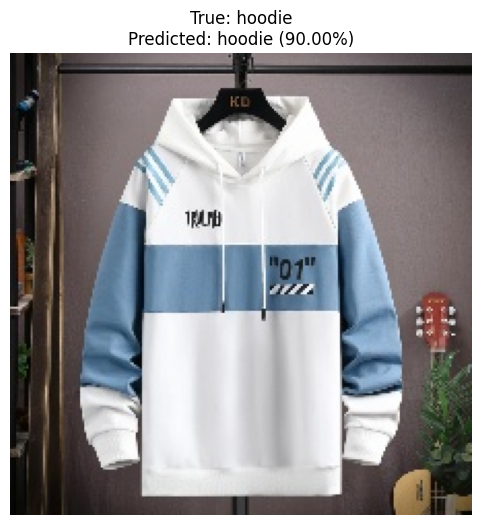

Index: 500
Image: /content/extracted_dataset/images/500.jpg
True class: hoodie
Predicted item: hoodie

Top 3 predictions:
1. hoodie: 90.00%
2. tshirt: 9.90%
3. glasses: 0.06%


In [ ]:
show_top3_predictions(500)

In [ ]:
feature_extractor = tf.keras.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer("mobilenet_feature_vector").output
)

feature_extractor.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_feature_vector        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
def extract_mobilenet_feature(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    feature = feature_extractor.predict(img, verbose=0)
    return feature[0]

features = []

for path in df[PATH_COL].values:
    features.append(extract_mobilenet_feature(path))

features = np.array(features)
all_labels = df["label"].values

print("Features shape:", features.shape)
print("Labels shape:", all_labels.shape)

Features shape: (518, 1280)
Labels shape: (518,)


In [ ]:
feature_norms = np.linalg.norm(features, axis=1, keepdims=True)
features_norm = features / (feature_norms + 1e-8)

print("Normalized features shape:", features_norm.shape)

Normalized features shape: (518, 1280)


In [ ]:
FEATURE_DIM = features_norm.shape[1]
LATENT_DIM = 128

ae_input = tf.keras.layers.Input(shape=(FEATURE_DIM,))

encoded = tf.keras.layers.Dense(512, activation="relu")(ae_input)
encoded = tf.keras.layers.Dropout(0.2)(encoded)
encoded = tf.keras.layers.Dense(256, activation="relu")(encoded)
latent = tf.keras.layers.Dense(LATENT_DIM, activation="relu", name="latent_vector")(encoded)

decoded = tf.keras.layers.Dense(256, activation="relu")(latent)
decoded = tf.keras.layers.Dense(512, activation="relu")(decoded)
ae_output = tf.keras.layers.Dense(FEATURE_DIM, activation="linear")(decoded)

autoencoder = tf.keras.Model(ae_input, ae_output, name="Autoencoder_Recommender")
encoder = tf.keras.Model(ae_input, latent, name="Autoencoder_Encoder")

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()
encoder.summary()

Model: "Autoencoder_Recommender"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1280)           │       656,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,641,344 (6.26 MB)

 Trainable params: 1,641,344 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

Model: "Autoencoder_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,096 (3.13 MB)

 Trainable params: 820,096 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ae_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/models/best_autoencoder.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history_ae = autoencoder.fit(
    features_norm,
    features_norm,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=ae_callbacks,
    verbose=1
)

autoencoder.save("/content/models/final_autoencoder.keras")
encoder.save("/content/models/final_encoder.keras")

print("Autoencoder trained and saved.")

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 6.3921e-04
Epoch 1: val_loss improved from None to 0.00049, saving model to /content/models/best_autoencoder.keras

Epoch 1: finished saving model to /content/models/best_autoencoder.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 5.4992e-04 - val_loss: 4.9374e-04
Epoch 2/100
19/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5730e-04 
Epoch 2: val_loss improved from 0.00049 to 0.00049, saving model to /content/models/best_autoencoder.keras

Epoch 2: finished saving model to /content/models/best_autoencoder.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5703e-04 - val_loss: 4.8789e-04
Epoch 3/100
18/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4974e-04 
Epoch 3: val_loss improved from 0.00049 to 0.00048, saving model to /content/models/best_autoencoder.keras

Epoch 3: finished saving model to /content/models/best_autoencoder.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4728e-04 - val_loss: 4.7953e-04


In [ ]:
latent_features = encoder.predict(features_norm, verbose=0)

print("Latent features shape:", latent_features.shape)

class_latent_bank = {}

for class_id in range(NUM_CLASSES):
    idxs = np.where(all_labels == class_id)[0]

    if len(idxs) > 0:
        class_latent_bank[class_id] = np.mean(latent_features[idxs], axis=0)

print("Class latent bank ready:", [id_to_class[k] for k in class_latent_bank.keys()])

Latent features shape: (518, 128)
Class latent bank ready: ['dress', 'glasses', 'hoodie', 'jacket', 'jeans', 'shorts', 'sneakers', 'tshirt']


In [ ]:
def autoencoder_recommendation(predicted_class_id, top_k=3):
    if predicted_class_id not in class_latent_bank:
        return []

    source_vec = class_latent_bank[predicted_class_id].reshape(1, -1)

    sims = []

    for class_id, vec in class_latent_bank.items():
        if class_id == predicted_class_id:
            continue

        sim = cosine_similarity(source_vec, vec.reshape(1, -1))[0][0]
        sims.append((class_id, sim))

    sims = sorted(sims, key=lambda x: x[1], reverse=True)

    return [id_to_class[class_id] for class_id, score in sims[:top_k]]

In [ ]:
outfit_rules = {
    "glasses": ["tshirt", "jeans", "sneakers"],
    "tshirt": ["glasses", "jeans", "sneakers"],
    "jeans": ["tshirt", "glasses", "sneakers"],
    "sneakers": ["tshirt", "jeans", "glasses"],
    "hoodie": ["jeans", "sneakers", "glasses"],
    "jacket": ["tshirt", "jeans", "sneakers"],
    "dress": ["glasses", "sneakers"],
    "shorts": ["tshirt", "sneakers", "glasses"]
}

def final_autoencoder_outfit(predicted_item):
    if predicted_item in outfit_rules:
        return outfit_rules[predicted_item]

    predicted_class_id = label_map[predicted_item]
    return autoencoder_recommendation(predicted_class_id, top_k=3)

In [ ]:
def full_outfit_prediction_mobilenet_autoencoder(index):
    row = df.iloc[index]

    image_path = row[PATH_COL]
    true_class = row["class_name"]

    predicted_class_id, predicted_item, confidence, pred = cnn_predict(image_path)

    ae_recommendations = autoencoder_recommendation(predicted_class_id, top_k=3)
    final_recommendations = final_autoencoder_outfit(predicted_item)

    img = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_item} ({confidence:.2%})"
    )
    plt.show()

    top3_ids = np.argsort(pred)[-3:][::-1]

    print("Index:", index)
    print("Image:", image_path)
    print("True class:", true_class)
    print("Predicted item:", predicted_item)

    print("\nTop 3 CNN predictions:")
    for rank, cid in enumerate(top3_ids, start=1):
        cid = int(cid)
        print(f"{rank}. {id_to_class[cid]}: {pred[cid]:.2%}")

    print("\nAutoencoder visual recommendations:")
    print(ae_recommendations)

    print("\nFinal outfit recommendations:")
    print(final_recommendations)

    return {
        "true_class": true_class,
        "predicted_item": predicted_item,
        "confidence": confidence,
        "top3": [(id_to_class[int(cid)], float(pred[int(cid)])) for cid in top3_ids],
        "autoencoder_recommendations": ae_recommendations,
        "final_recommendations": final_recommendations
    }

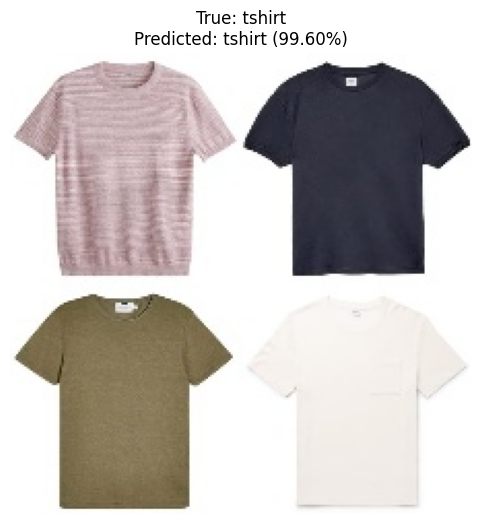

Index: 0
Image: /content/extracted_dataset/images/0.jpg
True class: tshirt
Predicted item: tshirt

Top 3 CNN predictions:
1. tshirt: 99.60%
2. hoodie: 0.31%
3. jeans: 0.03%

Autoencoder visual recommendations:
['hoodie', 'glasses', 'jacket']

Final outfit recommendations:
['glasses', 'jeans', 'sneakers']


In [ ]:
result = full_outfit_prediction_mobilenet_autoencoder(0)

In [ ]:
# ============================================================
# AutoEncoder
# ============================================================

from tensorflow.keras import layers, Model

input_img = layers.Input(shape=(224, 224, 3))

# ------------------------------------------------------------
# Encoder
# ------------------------------------------------------------

x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Flatten()(x)

latent = layers.Dense(256, activation='relu')(x)

# ------------------------------------------------------------
# Decoder
# ------------------------------------------------------------

x = layers.Dense(28 * 28 * 128, activation='relu')(latent)

x = layers.Reshape((28, 28, 128))(x)

x = layers.Conv2DTranspose(128, 3, strides=2,
                           activation='relu',
                           padding='same')(x)

x = layers.Conv2DTranspose(64, 3, strides=2,
                           activation='relu',
                           padding='same')(x)

x = layers.Conv2DTranspose(32, 3, strides=2,
                           activation='relu',
                           padding='same')(x)

decoded = layers.Conv2D(
    3,
    3,
    activation='sigmoid',
    padding='same'
)(x)

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

autoencoder = Model(input_img, decoded)

encoder = Model(input_img, latent)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100352)         │    25,790,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 56, 56, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 112, 112, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 224, 224, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,814,787 (197.66 MB)

 Trainable params: 51,814,787 (197.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Train AutoEncoder
# ============================================================

autoencoder.fit(
    train_ds.map(lambda x, y: (x, x)),
    validation_data=val_ds.map(lambda x, y: (x, x)),
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 693ms/step - loss: 0.4765 - val_loss: 0.3458
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.3360 - val_loss: 0.2926
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.3022 - val_loss: 0.2802
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.2906 - val_loss: 0.2729
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.2790 - val_loss: 0.2644
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.2692 - val_loss: 0.2585
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.2623 - val_loss: 0.2546
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.2568 - val_loss: 0.2511
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.2509 - val_loss: 0.2478
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.2444 - val_loss: 0.2450


In [ ]:
# ============================================================
# Extract latent features
# ============================================================

features = []
all_labels = []
all_paths = []

for i in range(len(df)):

    row = df.iloc[i]

    path = row[PATH_COL]

    label = row["label"]

    try:

        img = Image.open(path).convert("RGB")
        img = img.resize((224, 224))

        img_array = np.array(img) / 255.0

        feature = encoder.predict(
            np.expand_dims(img_array, axis=0),
            verbose=0
        )[0]

        features.append(feature)
        all_labels.append(label)
        all_paths.append(path)

    except:
        pass

features = np.array(features)

all_labels = np.array(all_labels)

print(features.shape)

(518, 256)


In [ ]:
# ============================================================
# Outfit completion labels
# ============================================================

outfit_rules = {

    "glasses": ["tshirt", "jeans", "sneakers"],

    "tshirt": ["glasses", "jeans", "sneakers"],

    "hoodie": ["jeans", "sneakers"],

    "jacket": ["jeans", "sneakers"],

    "dress": ["glasses", "sneakers"],

    "shorts": ["tshirt", "sneakers"]
}

In [ ]:
X_rec = []
y_rec = []

for i in range(len(df)):

    row = df.iloc[i]

    class_name = row["class_name"]

    if class_name not in outfit_rules:
        continue

    path = row[PATH_COL]

    try:

        img = Image.open(path).convert("RGB")
        img = img.resize((224, 224))

        img_array = np.array(img) / 255.0

        feature = encoder.predict(
            np.expand_dims(img_array, axis=0),
            verbose=0
        )[0]

        label_vector = np.zeros(NUM_CLASSES)

        for item in outfit_rules[class_name]:

            label_vector[label_map[item]] = 1

        X_rec.append(feature)

        y_rec.append(label_vector)

    except:
        pass

X_rec = np.array(X_rec)

y_rec = np.array(y_rec)

print(X_rec.shape)
print(y_rec.shape)

(379, 256)
(379, 8)


In [ ]:
recommendation_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(256,)),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="sigmoid"
    )
])

recommendation_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

recommendation_model.summary()

history = recommendation_model.fit(
    X_rec,
    y_rec,
    epochs=20,
    batch_size=16
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,672 (162.78 KB)

 Trainable params: 41,672 (162.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2058 - loss: 0.5289
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.3635
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1609 - loss: 0.3261
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.3134
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.2806
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.2665
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.2557
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1636 - loss: 0.2486
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1609 - loss: 0.2269
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1583 - loss: 0.2247
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1583 - loss: 0.2246
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1583 - l

In [ ]:
def complete_outfit(index, threshold=0.5):

    row = df.iloc[index]

    image_path = row[PATH_COL]

    img = Image.open(image_path).convert("RGB")

    img_resized = img.resize((224, 224))

    img_array = np.array(img_resized) / 255.0

    # --------------------------------------------------------
    # Extract encoder features
    # --------------------------------------------------------

    feature = encoder.predict(
        np.expand_dims(img_array, axis=0),
        verbose=0
    )[0]

    # --------------------------------------------------------
    # Predict outfit items
    # --------------------------------------------------------

    pred = recommendation_model.predict(
        np.expand_dims(feature, axis=0),
        verbose=0
    )[0]

    recommended_items = []

    for i, score in enumerate(pred):

        if score > threshold:

            recommended_items.append(
                id_to_class[i]
            )

    # --------------------------------------------------------
    # Visual display
    # --------------------------------------------------------

    total = len(recommended_items) + 1

    fig, axes = plt.subplots(
        1,
        total,
        figsize=(5 * total, 5)
    )

    # Input image

    axes[0].imshow(img)

    axes[0].axis("off")

    axes[0].set_title("Input")

    # Recommendations

    for idx, item in enumerate(recommended_items):

        class_rows = df[df["class_name"] == item]

        if len(class_rows) == 0:
            continue

        rec_row = class_rows.sample(1).iloc[0]

        rec_img = Image.open(
            rec_row[PATH_COL]
        ).convert("RGB")

        axes[idx + 1].imshow(rec_img)

        axes[idx + 1].axis("off")

        axes[idx + 1].set_title(item)

    plt.tight_layout()

    plt.show()

    print("Recommended items:")

    for item in recommended_items:
        print("-", item)

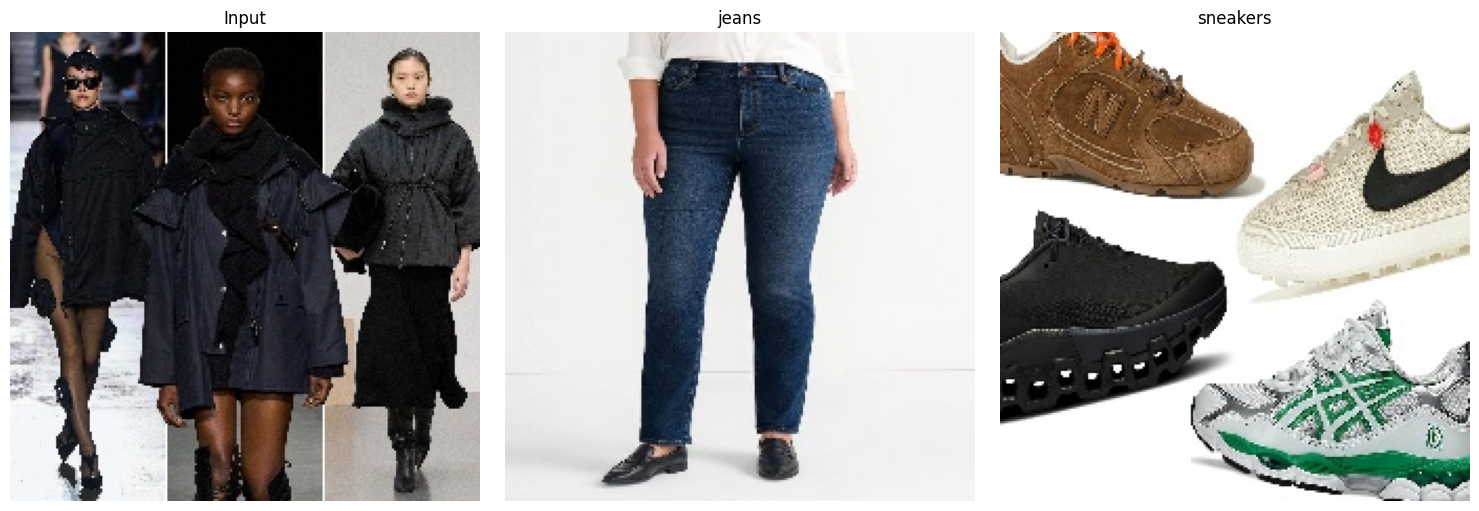

Recommended items:
- jeans
- sneakers


In [ ]:
complete_outfit(77)